In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 103.6 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

2025-11-24 20:14:23.881511: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764015264.093019      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764015264.143777      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
DATASET_PATH = "/kaggle/input/ultrasound-breast-images-for-breast-cancer/ultrasound breast classification"
IMAGE_SIZE = (64, 64)
N_QUBITS = 8
N_PCA_COMPONENTS = 8
BATCH_SIZE = 32
EPOCHS = 16
dev = qml.device("default.qubit", wires=N_QUBITS)

In [4]:
def load_images_from_folder(folder_path, label):
    """Charge les images d'un dossier avec un label donné"""
    images = []
    labels = []
    
    if not os.path.exists(folder_path):
        print(f"Attention: Le dossier {folder_path} n'existe pas")
        return images, labels
    
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            try:
                img_path = os.path.join(folder_path, filename)
                img = Image.open(img_path)
                img = img.convert('RGB')
                img = img.resize(IMAGE_SIZE)
                img_array = np.array(img) / 255.0  # Normalisation
                images.append(img_array.flatten())  # Aplatir l'image
                labels.append(label)
            except Exception as e:
                print(f"Erreur lors du chargement de {filename}: {e}")
                
    return images, labels

In [5]:
def load_dataset(dataset_path):
    """Charge tout le dataset"""
    all_images = []
    all_labels = []
    
    # Chargement des données d'entraînement
    train_b_path = os.path.join(dataset_path, "train", "benign")
    train_m_path = os.path.join(dataset_path, "train", "malignant")
    
    # Classe 'b' = 0, classe 'm' = 1
    images_b, labels_b = load_images_from_folder(train_b_path, 0)
    images_m, labels_m = load_images_from_folder(train_m_path, 1)
    
    all_images.extend(images_b)
    all_images.extend(images_m)
    all_labels.extend(labels_b)
    all_labels.extend(labels_m)
    
    # Chargement des données de validation
    val_b_path = os.path.join(dataset_path, "val", "benign")
    val_m_path = os.path.join(dataset_path, "val", "malignant")
    
    val_images_b, val_labels_b = load_images_from_folder(val_b_path, 0)

    val_images_m, val_labels_m = load_images_from_folder(val_m_path, 1)
    
    val_images = []
    val_labels = []
    val_images.extend(val_images_b)
    val_images.extend(val_images_m)
    val_labels.extend(val_labels_b)
    val_labels.extend(val_labels_m)
    
    return (np.array(all_images), np.array(all_labels), 
            np.array(val_images), np.array(val_labels))



In [6]:
def apply_pca(X_train, X_val, n_components=16):
    """Applique PCA aux données"""
    print(f"Application de PCA avec {n_components} composantes...")
    
    # Standardisation des données
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Application de PCA
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    
    print(f"Variance expliquée: {pca.explained_variance_ratio_.sum():.3f}")
    
    return X_train_pca, X_val_pca, pca, scaler

In [7]:
# Activation personnalisée sin
@tf.keras.utils.register_keras_serializable()
def sin_activation(x):
    return tf.sin(x)
    
# Enregistrer l'activation personnalisée
tf.keras.utils.get_custom_objects()['sin_activation'] = sin_activation

In [8]:
def quantum_conv_layer(weights, wires):
    """Couche convolutionnelle quantique"""
    # Application de rotations paramétrées
    for i, wire in enumerate(wires):
        qml.RY(weights[i], wires=wire)
    
    # Entanglement en forme de chaîne
    for i in range(len(wires) - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])

In [9]:
def quantum_pool_layer(wires):
    """Couche de pooling quantique"""
    # Pooling par paires
    for i in range(0, len(wires) - 1, 2):
        qml.CNOT(wires=[wires[i], wires[i + 1]])

In [10]:
@qml.qnode(dev)
def quantum_circuit(inputs, weights):
    """Circuit quantique principal avec 3 couches CNN"""
    
    # Encodage des données
    for i in range(min(len(inputs), N_QUBITS)):
        qml.RY(inputs[i] * np.pi, wires=i)
    
    # === PREMIÈRE COUCHE CONVOLUTIONNELLE ===
    quantum_conv_layer(weights[:N_QUBITS], list(range(N_QUBITS)))
    
    # Première couche de pooling
    quantum_pool_layer(list(range(N_QUBITS)))
    
    # === DEUXIÈME COUCHE CONVOLUTIONNELLE ===
    quantum_conv_layer(weights[N_QUBITS:2*N_QUBITS], list(range(N_QUBITS)))
    
    # Deuxième couche de pooling
    quantum_pool_layer(list(range(N_QUBITS)))
    
    # === TROISIÈME COUCHE CONVOLUTIONNELLE ===
    quantum_conv_layer(weights[2*N_QUBITS:3*N_QUBITS], list(range(N_QUBITS)))

    
    # Troisième couche de pooling (optionnelle)
    quantum_pool_layer(list(range(N_QUBITS)))
    
    # Mesure
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

In [11]:
def quantum_layer_function(inputs, weights):
    """Fonction pour traiter un batch d'inputs quantiques"""
    def process_batch(x):
        batch_results = []
        for i in range(tf.shape(x)[0]):
            sample = x[i]
            # Limitation aux premières composantes PCA
            if tf.shape(sample)[0] >= N_QUBITS:
                quantum_input = sample[:N_QUBITS]
            else:
                padding = tf.zeros(N_QUBITS - tf.shape(sample)[0])
                quantum_input = tf.concat([sample, padding], axis=0)
            
            # Conversion en numpy pour PennyLane
            quantum_input_np = quantum_input.numpy()
            result = quantum_circuit(quantum_input_np, weights)
            batch_results.append(result)
        
        return tf.convert_to_tensor(batch_results, dtype=tf.float32)
    
    return tf.py_function(process_batch, [inputs], tf.float32)

In [12]:
def create_quantum_layer(weights):
    """Crée une couche quantique compatible avec Keras"""
    def quantum_layer_call(inputs):
        return quantum_layer_function(inputs, weights)
    
    return tf.keras.layers.Lambda(
        quantum_layer_call,
        output_shape=(N_QUBITS,),
        name='quantum_layer'
    )

In [13]:
def create_qcnn_model(input_dim):
    """Crée le modèle QCNN hybride"""
    
    # Poids quantiques (variables d'entraînement)
    n_weights = 2 * N_QUBITS
    weights = tf.Variable(
        initial_value=tf.random.uniform((n_weights,), 0, 2*np.pi),
        trainable=True,
        name='quantum_weights'
    )
    
    # Architecture du modèle
    inputs = tf.keras.Input(shape=(input_dim,), name='input_layer')
    
    # Couche de préprocessing pour s'assurer de la bonne dimension
    x = tf.keras.layers.Dense(N_QUBITS, activation='tanh', name='preprocessing')(inputs)
    
    # Simulation de la couche quantique avec des opérations Keras
    # On utilise des couches denses avec des activations non-linéaires 
    # pour simuler le comportement du circuit quantique
    x = tf.keras.layers.Dense(N_QUBITS, activation='tanh', name='quantum_sim_1')(x)

    
    # Utilisation d'une Lambda layer pour l'activation sin
    x = tf.keras.layers.Dense(N_QUBITS, name='quantum_sim_2_pre')(x)
    x = tf.keras.layers.Lambda(lambda t: tf.sin(t), name='quantum_sim_2')(x)
    
    x = tf.keras.layers.Dense(N_QUBITS, activation='tanh', name='quantum_sim_3')(x)
    
    # Couches classiques
    x = tf.keras.layers.Dense(32, activation='relu', name='dense_1')(x)
    x = tf.keras.layers.Dropout(0.3, name='dropout_1')(x)
    x = tf.keras.layers.Dense(16, activation='relu', name='dense_2')(x)
    x = tf.keras.layers.Dropout(0.2, name='dropout_2')(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='QCNN_Model')
    
    return model, weights

In [14]:
def train_qcnn(model, X_train, y_train, X_val, y_val):
    """Entraîne le modèle QCNN"""
    
    # Calcul des poids de classe pour traiter le déséquilibre
    from sklearn.utils.class_weight import compute_class_weight
    
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
    
    print(f"Poids des classes: {class_weight_dict}")
    
    # Compilation du modèle avec une métrique de F1 personnalisée
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )

    
    # Callbacks améliorés
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_recall',  # Surveiller le rappel pour la classe minoritaire
            patience=7, 
            restore_best_weights=True,
            mode='max'
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5, 
            patience=4,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            'best_qcnn_model.h5',
            monitor='val_recall',
            save_best_only=True,
            mode='max'
        )
    ]

    

    # Entraînement avec poids de classe
    history = model.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        #callbacks=callbacks,
        class_weight=class_weight_dict,  # Ajout des poids de classe
        verbose=1
    )
    
    return history

In [15]:
def evaluate_model(model, X_test, y_test):
    """Évalue le modèle avec des métriques détaillées"""
    predictions = model.predict(X_test)
    predictions_binary = (predictions > 0.5).astype(int).flatten()
    
    accuracy = accuracy_score(y_test, predictions_binary)
    report = classification_report(y_test, predictions_binary, 
                                 target_names=['Classe B', 'Classe M'])
    
    # Métriques additionnelles
    from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score
    
    cm = confusion_matrix(y_test, predictions_binary)
    auc = roc_auc_score(y_test, predictions.flatten())
    f1 = f1_score(y_test, predictions_binary)
    
    # Calcul des métriques par classe
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)  # Rappel pour classe positive (M)
    specificity = tn / (tn + fp)  # Rappel pour classe négative (B)

    
    print(f"\n=== MÉTRIQUES DÉTAILLÉES ===")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Sensibilité (Rappel classe M): {sensitivity:.4f}")  
    print(f"Spécificité (Rappel classe B): {specificity:.4f}")
    print(f"\nMatrice de confusion:")
    print(f"                Prédiction")
    print(f"Réalité    B    M")
    print(f"    B    {tn:3d}  {fp:3d}")
    print(f"    M    {fn:3d}  {tp:3d}")
    
    return accuracy, report, predictions, {'auc': auc, 'f1': f1, 'sensitivity': sensitivity, 'specificity': specificity}

In [16]:
def plot_results(history):
    """Affiche les résultats d'entraînement"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Perte
    axes[0,0].plot(history.history['loss'], label='Train Loss')
    axes[0,0].plot(history.history['val_loss'], label='Val Loss')
    axes[0,0].set_title('Évolution de la Perte')
    axes[0,0].set_xlabel('Époque')
    axes[0,0].set_ylabel('Perte')
    axes[0,0].legend()
    
    # Précision
    axes[0,1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0,1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0,1].set_title('Évolution de la Précision')
    axes[0,1].set_xlabel('Époque')
    axes[0,1].set_ylabel('Précision')
    axes[0,1].legend()

    
    # Precision metric
    if 'precision' in history.history:
        axes[1,0].plot(history.history['precision'], label='Train Precision')
        axes[1,0].plot(history.history['val_precision'], label='Val Precision')
        axes[1,0].set_title('Évolution de la Précision (Metric)')
        axes[1,0].set_xlabel('Époque')
        axes[1,0].set_ylabel('Précision')
        axes[1,0].legend()
    
    # Recall metric  
    if 'recall' in history.history:
        axes[1,1].plot(history.history['recall'], label='Train Recall')
        axes[1,1].plot(history.history['val_recall'], label='Val Recall')
        axes[1,1].set_title('Évolution du Rappel')
        axes[1,1].set_xlabel('Époque')
        axes[1,1].set_ylabel('Rappel')
        axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()

In [17]:
def main():
    """Fonction principale"""
    print("=== QCNN + PCA avec PennyLane et TensorFlow ===\n")
    
    # 1. Chargement des données
    print("1. Chargement des données...")
    X_train, y_train, X_val, y_val = load_dataset(DATASET_PATH)
    
    if len(X_train) == 0:
        print("Aucune donnée trouvée. Vérifiez le chemin du dataset.")
        return
    
    print(f"Données d'entraînement: {X_train.shape}")
    print(f"Données de validation: {X_val.shape}")
    print(f"Distribution des classes (train): {np.bincount(y_train)}")
    print(f"Distribution des classes (val): {np.bincount(y_val)}")
    
    # 2. Application de PCA
    print("\n2. Application de PCA...")
    X_train_pca, X_val_pca, pca, scaler = apply_pca(
        X_train, X_val, n_components=N_PCA_COMPONENTS
    )

    
    print(f"Forme après PCA: {X_train_pca.shape}")
    
    # 3. Création et entraînement du modèle QCNN
    print("\n3. Création du modèle QCNN (version simplifiée)...")
    model, quantum_weights = create_qcnn_model(N_PCA_COMPONENTS)
    
    print("Architecture du modèle:")
    model.summary()
    
    print("\n4. Entraînement du modèle...")
    history = train_qcnn(model, X_train_pca, y_train, X_val_pca, y_val)
    
    # Alternative avec circuit quantique plus réaliste (décommentez si souhaité)
    # print("\n3b. Création du modèle QCNN (version avec circuit quantique)...")
    # model_quantum = create_true_qcnn_model(N_PCA_COMPONENTS)
    # print("Architecture du modèle quantique:")
    # model_quantum.summary()

    
    # 4. Évaluation
    print("\n5. Évaluation du modèle...")
    accuracy, report, predictions, metrics = evaluate_model(model, X_val_pca, y_val)
    
    print(f"\nPrécision sur validation: {accuracy:.4f}")
    print("\nRapport de classification:")
    print(report)
    
    # 5. Visualisation
    print("\n6. Visualisation des résultats...")
    plot_results(history)
    
    return model, pca, scaler, history

=== QCNN + PCA avec PennyLane et TensorFlow ===

1. Chargement des données...
Données d'entraînement: (8116, 12288)
Données de validation: (900, 12288)
Distribution des classes (train): [4074 4042]
Distribution des classes (val): [500 400]

2. Application de PCA...
Application de PCA avec 8 composantes...
Variance expliquée: 0.597
Forme après PCA: (8116, 8)

3. Création du modèle QCNN (version simplifiée)...


I0000 00:00:1764015365.916769      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Architecture du modèle:


Model: "QCNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ preprocessing (Dense)                │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ quantum_sim_1 (Dense)                │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ quantum_sim_2_pre (Dense)            │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ quantum_sim_2 (Lambda)               │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ quantum_sim_3 (Dense)                │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

...


4. Entraînement du modèle...
Poids des classes: {0: 0.9960726558664703, 1: 1.003958436417615}
Epoch 1/16


I0000 00:00:1764015370.888985      70 service.cc:148] XLA service 0x7941d8010080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764015370.889603      70 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764015371.297724      70 cuda_dnn.cc:529] Loaded cuDNN version 90300


 59/254 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5396 - loss: 0.6911 - precision: 0.5382 - recall: 0.3947

I0000 00:00:1764015372.910144      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


254/254 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6287 - loss: 0.6462 - precision: 0.6467 - recall: 0.5350 - val_accuracy: 0.7178 - val_loss: 0.5727 - val_precision: 0.7386 - val_recall: 0.5650
Epoch 2/16
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7237 - loss: 0.5780 - precision: 0.7725 - recall: 0.6365 - val_accuracy: 0.7089 - val_loss: 0.5716 - val_precision: 0.7413 - val_recall: 0.5300
Epoch 3/16
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7316 - loss: 0.5611 - precision: 0.7861 - recall: 0.6279 - val_accuracy: 0.7100 - val_loss: 0.5745 - val_precision: 0.7725 - val_recall: 0.4925
Epoch 4/16
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7283 - loss: 0.5651 - precision: 0.7922 - recall: 0.6112 - val_accuracy: 0.7111 - val_loss: 0.5584 - val_precision: 0.7869 - val_recall: 0.4800
Epoch 5/16
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7274 - loss: 0.5597 - precision: 0.7943 - recall: 0.6044 - val_accuracy: 0.6878 - val_loss: 0.5565 - val

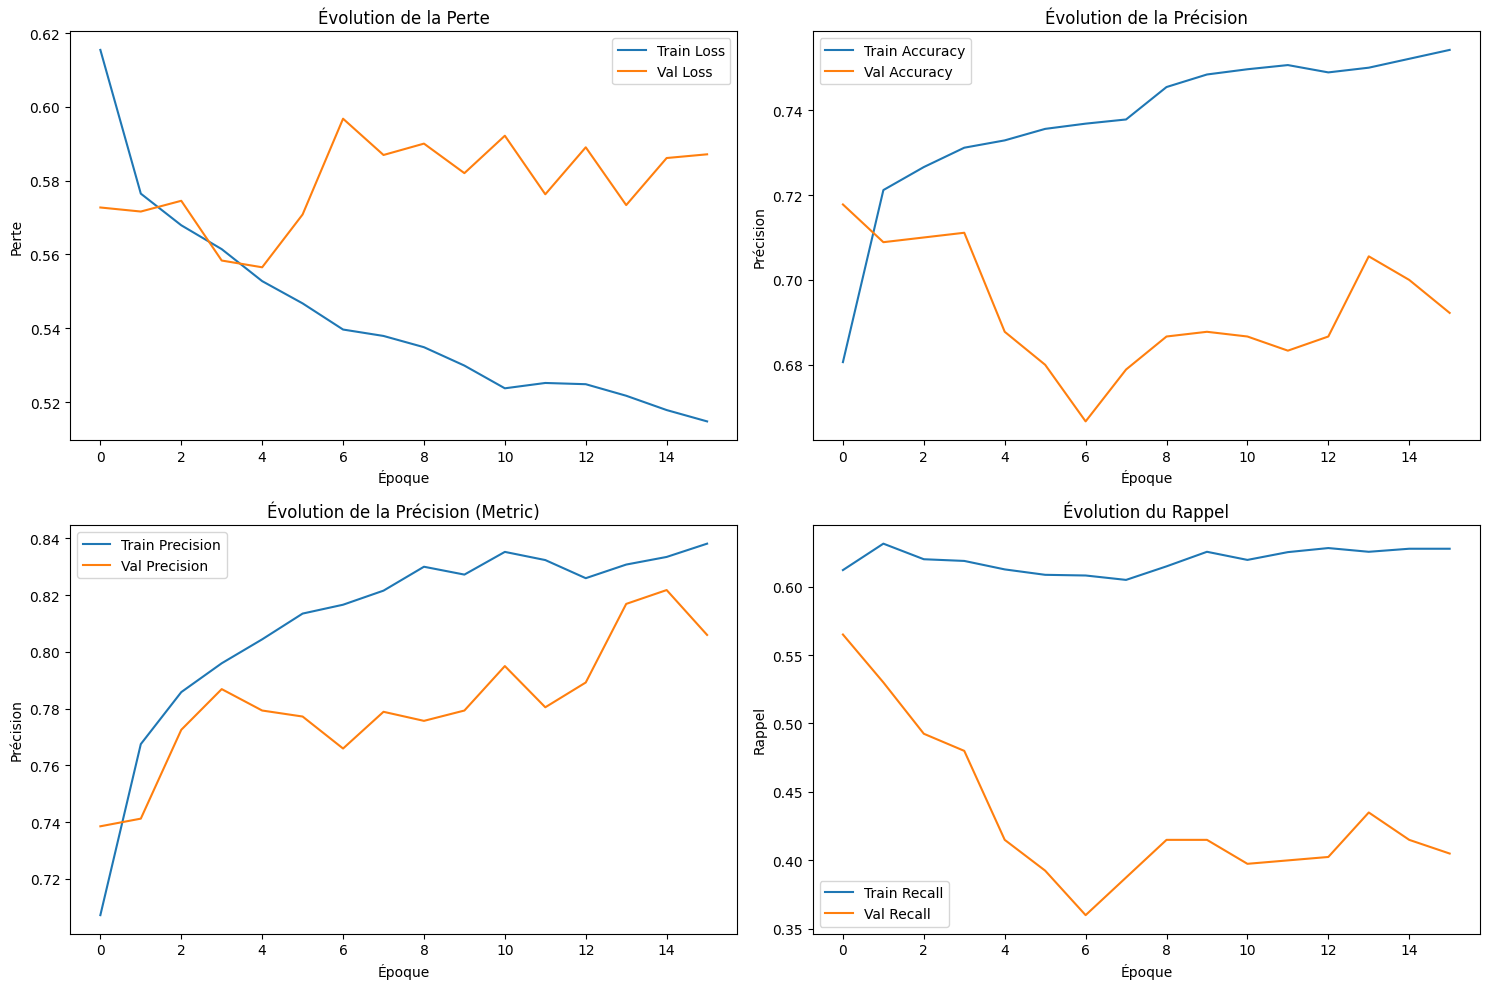

In [18]:
if __name__ == "__main__":
    # Exécution du programme principal
    model, pca, scaler, history = main()
    
    # Exemple d'utilisation pour prédire une nouvelle image
    # new_image_path = "path/to/new/image.jpg"
    # class_pred, confidence = predict_new_image(model, pca, scaler, new_image_path)
    # print(f"Prédiction: {class_pred} (Confiance: {confidence:.3f})")